In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
from unsloth import FastLanguageModel
import torch
from datasets import load_dataset
import json

# --- STEP 1: LOAD MODEL ---
max_seq_length = 2048
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "meta-llama/Llama-3.1-8B",
    max_seq_length = max_seq_length,
    load_in_4bit = True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-04 05:18:40.904195: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772601521.139655      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772601521.203435      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772601521.747254      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772601521.747297      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772601521.747300      55 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.3.3: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.96G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

In [3]:
# --- STEP 2: PREPARE DATASET ---
from datasets import load_dataset

# 1. Define your prompt template
alpaca_prompt = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{}

### Input:
{}

### Response:
{}"""

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for inst, inp, out in zip(instructions, inputs, outputs):
        # Format the text and add the EOS token
        text = alpaca_prompt.format(inst, inp, out) + tokenizer.eos_token
        texts.append(text)
    return { "text" : texts }

# 2. LOAD SEPARATE FILES DIRECTLY
# Replace these paths with the actual locations of your split files
dataset = load_dataset("json", data_files={
    "train": "/kaggle/input/datasets/anandarimal/trainingset/training.json", 
    "test":  "/kaggle/input/datasets/anandarimal/testingset/testing.json"
})

# 3. Apply the mapping to both sets
train_dataset = dataset["train"].map(formatting_prompts_func, batched = True)
eval_dataset  = dataset["test"].map(formatting_prompts_func, batched = True)

# Keep a raw copy of test data for manual evaluation/scoring later
eval_dataset_raw = dataset["test"]

print(f"Dataset loaded. Train size: {len(train_dataset)}, Test size: {len(eval_dataset)}")

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset loaded. Train size: 9000, Test size: 1000


In [4]:
!pip install evaluate sacrebleu rouge-score bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.1 MB/s eta 0:00:00


In [5]:
from tqdm import tqdm
from evaluate import load
from bert_score import score as bert_score_fn
import math
import torch

def run_evaluation(model, tokenizer, dataset, title="Model"):
    print(f"\n🚀 Starting Evaluation: {title}")
    total_samples = len(dataset)

    # Load metrics
    bleu = load("bleu")
    chrf = load("chrf")
    rouge = load("rouge")

    predictions, references, total_loss = [], [], 0.0

    # Using enumerate for the sample counter
    for i, row in enumerate(tqdm(dataset, desc="Processing")):
        # 1. Generate Response (Hidden from print)
        prompt = alpaca_prompt.format(row['instruction'], row['input'], "")
        inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

        # We use a modest max_new_tokens to speed up base model testing
        outputs = model.generate(**inputs, max_new_tokens=128, use_cache=True)
        resp = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0].split("### Response:")[-1].strip()

        predictions.append(resp)
        references.append(row['output'])

        # 2. Perplexity Calculation
        full_text = alpaca_prompt.format(row['instruction'], row['input'], row['output'])
        encodings = tokenizer(full_text, return_tensors="pt").to("cuda")
        with torch.no_grad():
            loss = model(**encodings, labels=encodings["input_ids"]).loss
            total_loss += loss.item()

        # 3. Progress Print (Shows count only)
        # Using end="\r" keeps it on one line to keep the console clean
        print(f"✅ Sample {i+1}/{total_samples} done", end="\r")

    # 4. Final Calculations
    print(f"\n\n🧮 Calculating final scores for {title}...")

    # Perplexity Formula: $PPL = e^{(\frac{1}{N}\sum loss)}$
    ppl = math.exp(total_loss / total_samples)

    # BERTScore
    _, _, b_f1 = bert_score_fn(predictions, references, lang="bert-base-multilingual-cased")

    # Compute Standard Metrics
    rouge_results = rouge.compute(predictions=predictions, references=references)
    bleu_results = bleu.compute(predictions=predictions, references=[[r] for r in references])
    chrf_results = chrf.compute(predictions=predictions, references=[[r] for r in references], word_order=2)

    results = {
        "PPL": ppl,
        "BERT": b_f1.mean().item(),
        "BLEU": bleu_results['bleu'],
        "chrF++": chrf_results['score'],
        "ROUGE-1": rouge_results['rouge1'],
        "ROUGE-2": rouge_results['rouge2'],
        "ROUGE-L": rouge_results['rougeL']
    }

    print(f"✨ Evaluation Complete for {title}!")
    for metric, value in results.items():
        print(f"🔹 {metric}: {value:.4f}")

    return results

# Get Baseline
base_results = run_evaluation(model, tokenizer, eval_dataset_raw, "Base Model")


🚀 Starting Evaluation: Base Model


Processing:   0%|          | 1/1000 [00:27<7:32:18, 27.17s/it]

Processing:   0%|          | 2/1000 [00:32<3:55:58, 14.19s/it]

Processing:   0%|          | 3/1000 [00:39<3:03:09, 11.02s/it]

Processing:   0%|          | 4/1000 [00:46<2:38:36,  9.55s/it]

...

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

✨ Evaluation Complete for Base Model!
🔹 PPL: 52.7946
🔹 BERT: 0.4224
🔹 BLEU: 0.0143
🔹 chrF++: 8.1539
🔹 ROUGE-1: 0.0732
🔹 ROUGE-2: 0.0311
🔹 ROUGE-L: 0.0681


In [7]:
from transformers import TextStreamer

# 1. Switch to Inference Mode (Vital for Unsloth speed)
FastLanguageModel.for_inference(model)

# 2. Prepare the Prompt
instruction = "nepal ko barema bhanata"
input_context = "" # Leave empty if not needed

formatted_prompt = alpaca_prompt.format(instruction, input_context, "")

# 3. Tokenize
inputs = tokenizer([formatted_prompt], return_tensors = "pt").to("cuda")

# 4. Set up the Streamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True) # skip_prompt=True hides your input

# 5. Generate with Parameters
_ = model.generate(
    **inputs,
    streamer = text_streamer,
    max_new_tokens = 256,       # Increased for more detailed answers
    temperature = 0.3,          # Lower = more focused; Higher = more creative
    repetition_penalty = 1.1,   # Prevents the model from getting "stuck"
    use_cache = True
)

Nepal ko barema bhanatyo
<|end_of_text|>


In [8]:
base_results

{'PPL': 52.79456176442922,
 'BERT': 0.4224088788032532,
 'BLEU': 0.014303112756384559,
 'chrF++': 8.153870250047648,
 'ROUGE-1': np.float64(0.0732157305950471),
 'ROUGE-2': np.float64(0.031096258648468347),
 'ROUGE-L': np.float64(0.06808268489689691)}

In [10]:
from trl import SFTConfig, SFTTrainer

# 1. PEFT Model (Kept exactly as provided)
model = FastLanguageModel.get_peft_model(
model,
r = 32,
target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
lora_alpha = 64,
lora_dropout = 0,
bias = "none",
use_rslora = True,
)

# 2. Configuration & Trainer
trainer = SFTTrainer(
model = model,
tokenizer = tokenizer,
train_dataset = train_dataset,
eval_dataset = eval_dataset,
dataset_text_field = "text",
args = SFTConfig(
max_seq_length = max_seq_length,
per_device_train_batch_size = 2,
gradient_accumulation_steps = 4,
warmup_steps = 200,
num_train_epochs = 3,
learning_rate = 1e-4,
fp16 = not torch.cuda.is_bf16_supported(),
bf16 = torch.cuda.is_bf16_supported(),
logging_steps = 1,
eval_strategy = "steps",
eval_steps = 100,

# --- NEW CHECKPOINT SETTINGS ADDED BELOW ---
save_strategy = "steps", # Save based on step count
save_steps = 100, # Save a checkpoint every 100 steps (matches eval)
save_total_limit = 10, # Keeps the 10 best/most recent checkpoints to save disk space
load_best_model_at_end = True, # Automatically loads the "Golden Point" weights when finished
metric_for_best_model = "eval_loss",
# -------------------------------------------

optim = "adamw_8bit",
output_dir = "outputs",
),
)

Unsloth: Already have LoRA adapters! We shall skip this step.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/9000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [11]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,000 | Num Epochs = 3 | Total steps = 3,375
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 83,886,080 of 8,114,147,328 (1.03% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,2.096200,1.865180
200,2.026700,1.686658
300,1.968500,1.552862
400,1.391700,1.481734
500,1.371000,1.414422
600,1.637200,1.377166
700,1.393300,1.341539
800,1.305600,1.310754
900,0.995100,1.290939
1000,1.434800,1.262865


Unsloth: Not an error, but LlamaForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


TrainOutput(global_step=3375, training_loss=1.0055162387865562, metrics={'train_runtime': 31861.0597, 'train_samples_per_second': 0.847, 'train_steps_per_second': 0.106, 'total_flos': 2.2212078737139302e+17, 'train_loss': 1.0055162387865562, 'epoch': 3.0})

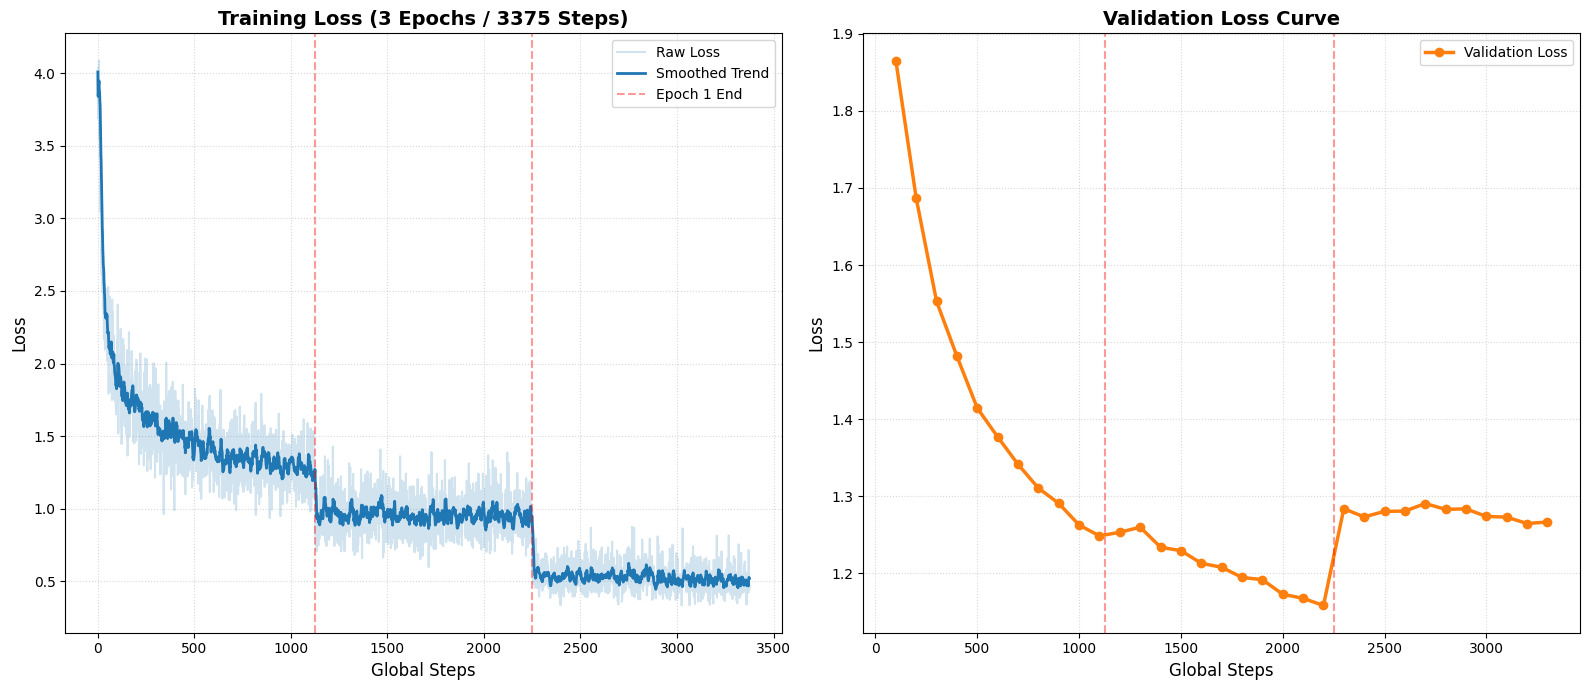

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_refined_losses(trainer, num_epochs=3):
    # 1. Extract raw logs
    history = trainer.state.log_history
    train_data = [x for x in history if 'loss' in x]
    eval_data = [x for x in history if 'eval_loss' in x]

    if not train_data:
        print("❌ No training data found. Did the model actually train?")
        return

    # 2. Prepare Training Data with Smoothing
    train_steps = [x['step'] for x in train_data]
    train_losses = [x['loss'] for x in train_data]

    # Apply Smoothing (Moving Average) to see the trend through the noise
    # Window size 10 means it averages the last 10 steps
    train_smooth = pd.Series(train_losses).rolling(window=10, min_periods=1).mean()

    # 3. Prepare Validation Data
    eval_steps = [x['step'] for x in eval_data]
    eval_losses = [x['eval_loss'] for x in eval_data]

    # 4. Calculate Epoch Markers
    total_steps = max(train_steps)
    steps_per_epoch = total_steps // num_epochs

    # 5. Create the Visuals
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # --- Plot 1: Training Loss (Raw + Smooth) ---
    ax1.plot(train_steps, train_losses, color='#1f77b4', alpha=0.2, label='Raw Loss')
    ax1.plot(train_steps, train_smooth, color='#1f77b4', lw=2, label='Smoothed Trend')

    # Add Epoch Vertical Lines
    for i in range(1, num_epochs):
        ax1.axvline(x=steps_per_epoch * i, color='red', linestyle='--', alpha=0.4, label=f'Epoch {i} End' if i==1 else "")

    ax1.set_title(f'Training Loss (3 Epochs / {total_steps} Steps)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Global Steps', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.legend()

    # --- Plot 2: Validation Loss ---
    if eval_losses:
        ax2.plot(eval_steps, eval_losses, color='#ff7f0e', lw=2.5, marker='o', markersize=6, label='Validation Loss')

        # Add Epoch Vertical Lines
        for i in range(1, num_epochs):
            ax2.axvline(x=steps_per_epoch * i, color='red', linestyle='--', alpha=0.4)

        ax2.set_title('Validation Loss Curve', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Global Steps', fontsize=12)
        ax2.set_ylabel('Loss', fontsize=12)
        ax2.grid(True, linestyle=':', alpha=0.5)
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, 'Validation data only appears\nevery 100 steps (eval_steps)',
                 ha='center', va='center', fontsize=12, color='gray')

    # 6. Save and Display
    plt.tight_layout()
    plt.savefig("roman_nepali_training_report.png", dpi=300)
    plt.show()

# Run it!
plot_refined_losses(trainer, num_epochs=3)

In [19]:
from transformers import TextStreamer

# 1. Switch to Inference Mode (Vital for Unsloth speed)
FastLanguageModel.for_inference(model)

# 2. Prepare the Prompt
instruction = "computer bhaneko k ho"
input_context = "" # Leave empty if not needed

formatted_prompt = alpaca_prompt.format(instruction, input_context, "")

# 3. Tokenize
inputs = tokenizer([formatted_prompt], return_tensors = "pt").to("cuda")

# 4. Set up the Streamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True) # skip_prompt=True hides your input

# 5. Generate with Parameters
_ = model.generate(
    **inputs,
    streamer = text_streamer,
    max_new_tokens = 256,       # Increased for more detailed answers
    temperature = 0.3,          # Lower = more focused; Higher = more creative
    repetition_penalty = 1.1,   # Prevents the model from getting "stuck"
    use_cache = True
)

kampyutara eka mesina ho jasale data prashodhana garna ra samasyaharu samadhana garna sakshama cha|<|end_of_text|>


In [ ]:
# Save just the adapters to Hugging Face
model.push_to_hub(
    "Ananda100/llamalora", 
    token = ""
)

README.md:   0%|          | 0.00/565 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Ananda100/llamalora


In [20]:
# --- STEP 5: FINAL EVAL
ft_results = run_evaluation(model, tokenizer, eval_dataset_raw, "Fine-Tuned Model")


🚀 Starting Evaluation: Fine-Tuned Model


Processing:   0%|          | 1/1000 [00:09<2:35:55,  9.36s/it]

Processing:   0%|          | 2/1000 [00:19<2:43:42,  9.84s/it]

Processing:   0%|          | 3/1000 [00:28<2:38:53,  9.56s/it]

Processing:   0%|          | 4/1000 [00:30<1:48:20,  6.53s/it]

...

Processing: 100%|█████████▉| 998/1000 [1:27:41<00:14,  7.33s/it]

Processing: 100%|█████████▉| 999/1000 [1:27:50<00:07,  7.93s/it]

Processing: 100%|██████████| 1000/1000 [1:27:59<00:00,  5.28s/it]

✅ Sample 1000/1000 done

🧮 Calculating final scores for Fine-Tuned Model...


✨ Evaluation Complete for Fine-Tuned Model!
🔹 PPL: 3.0239
🔹 BERT: 0.7511
🔹 BLEU: 0.0498
🔹 chrF++: 26.9680
🔹 ROUGE-1: 0.2756
🔹 ROUGE-2: 0.1002
🔹 ROUGE-L: 0.2359


In [21]:
ft_results

{'PPL': 3.0239201475254647,
 'BERT': 0.7510789632797241,
 'BLEU': 0.04980748930023704,
 'chrF++': 26.968008378559215,
 'ROUGE-1': np.float64(0.27555024403842754),
 'ROUGE-2': np.float64(0.10023283075697315),
 'ROUGE-L': np.float64(0.23588417327590772)}

In [22]:
print(f"The best model was found at: {trainer.state.best_model_checkpoint}")
print(f"The best loss achieved was: {trainer.state.best_metric}")

The best model was found at: outputs/checkpoint-2200
The best loss achieved was: 1.1585170030593872
